## E-Commerce Analytics


This notebook aims to perfom analytic calculations on the dataset from [Kaggle](https://www.kaggle.com/datasets/fahmidachowdhury/e-commerce-sales-analysis).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Reading the csv file into a dataframe:

In [2]:
df = pd.read_csv("ecommerce_sales_analysis.csv")
pd.set_option("display.float_format", "{:,.2f}".format)
print(df.head())
print(df.shape)
print(df.info())

   product_id product_name        category  price  review_score  review_count  \
0           1    Product_1        Clothing 190.40          1.70           220   
1           2    Product_2  Home & Kitchen 475.60          3.20           903   
2           3    Product_3            Toys 367.34          4.50           163   
3           4    Product_4            Toys 301.34          3.90           951   
4           5    Product_5           Books  82.23          4.20           220   

   sales_month_1  sales_month_2  sales_month_3  sales_month_4  sales_month_5  \
0            479            449             92            784            604   
1             21            989            861            863            524   
2            348            558            567            143            771   
3            725            678             59             15            937   
4            682            451            649            301            620   

   sales_month_6  sales_month_7 

Cleaning the data by checking for missing values, duplicates and displaying a summary:

In [3]:
# Missing values
print("Missing values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Basic statistics
print("\nSummary statistics:")
print(df.describe())

Missing values:
product_id        0
product_name      0
category          0
price             0
review_score      0
review_count      0
sales_month_1     0
sales_month_2     0
sales_month_3     0
sales_month_4     0
sales_month_5     0
sales_month_6     0
sales_month_7     0
sales_month_8     0
sales_month_9     0
sales_month_10    0
sales_month_11    0
sales_month_12    0
dtype: int64

Duplicate rows: 0

Summary statistics:
       product_id    price  review_score  review_count  sales_month_1  \
count    1,000.00 1,000.00      1,000.00      1,000.00       1,000.00   
mean       500.50   247.68          3.03        526.51         498.31   
std        288.82   144.61          1.17        282.27         289.94   
min          1.00     7.29          1.00          1.00           0.00   
25%        250.75   121.81          2.00        283.75         245.50   
50%        500.50   250.92          3.10        543.00         507.50   
75%        750.25   373.44          4.00        772.00      

# Reshaping to long format

The raw data is wide, meaning there is one row per product with 12 monthly sales columns. For time-aware analysis we melt the dataframe into long format. In this format there is one row per product per month. This makes month-based grouping and trend analysis possible.

In [4]:
month_cols = [c for c in df.columns if c.startswith('sales_month_')]

long_df = df.melt(
    id_vars=['product_id', 'product_name', 'category', 'price', 'review_score', 'review_count'],
    value_vars=month_cols,
    var_name='month',
    value_name='units_sold'
)
print(long_df.head())

   product_id product_name        category  price  review_score  review_count  \
0           1    Product_1        Clothing 190.40          1.70           220   
1           2    Product_2  Home & Kitchen 475.60          3.20           903   
2           3    Product_3            Toys 367.34          4.50           163   
3           4    Product_4            Toys 301.34          3.90           951   
4           5    Product_5           Books  82.23          4.20           220   

           month  units_sold  
0  sales_month_1         479  
1  sales_month_1          21  
2  sales_month_1         348  
3  sales_month_1         725  
4  sales_month_1         682  


# Business Framing
Given the data of sales across a year, we can derive which product categories should the retailer prioritize for investment, and which might be underperforming despite appearances.

This section explores category-level revenue, total sales and customer sentiment to produce a defensible ranking of categories by overall business performance.

First, we build a product-level summary for easier analysis.

In [5]:
long_df['revenue'] = long_df['units_sold'] * long_df['price']

# product level summary
product_summary = (
    long_df.groupby("product_id")
      .agg(
          product_name=("product_name", "first"),
          category=("category", "first"),
          price=("price", "first"),
          review_score=("review_score", "first"),
          review_count=("review_count", "first"),
          total_sales=("units_sold", "sum"),
          total_revenue=("revenue", "sum"),
      )
      .reset_index()
)

product_summary["avg_monthly_sales"] = (
    product_summary["total_sales"] / 12
)

print(product_summary.head())

   product_id product_name        category  price  review_score  review_count  \
0           1    Product_1        Clothing 190.40          1.70           220   
1           2    Product_2  Home & Kitchen 475.60          3.20           903   
2           3    Product_3            Toys 367.34          4.50           163   
3           4    Product_4            Toys 301.34          3.90           951   
4           5    Product_5           Books  82.23          4.20           220   

   total_sales  total_revenue  avg_monthly_sales  
0         6421   1,222,558.40             535.08  
1         6027   2,866,441.20             502.25  
2         5580   2,049,757.20             465.00  
3         5022   1,513,329.48             418.50  
4         6094     501,109.62             507.83  


By aggregating product totals by category, we can find out which categories sold the most.

In [6]:
category_sales = (
    product_summary.groupby("category")["total_sales"].sum().sort_values(ascending=False)
)
print(category_sales)

category
Books             938229
Toys              917101
Sports            916371
Electronics       845120
Health            834414
Clothing          826536
Home & Kitchen    742141
Name: total_sales, dtype: int64


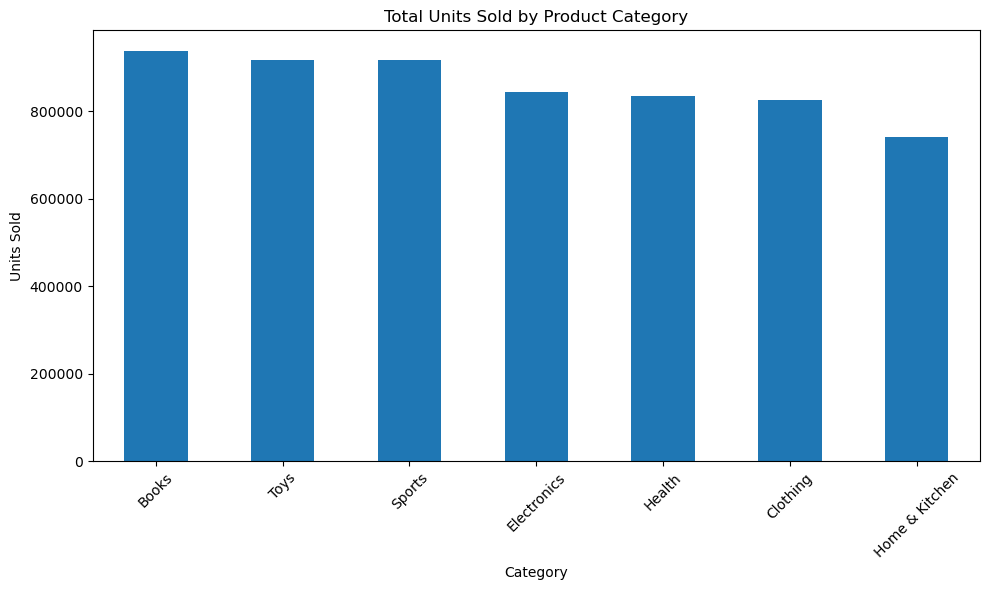

In [7]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Total Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
category_revenue = (
    product_summary.groupby("category")['total_revenue'].sum().sort_values(ascending=False)
)

print(category_revenue)

category
Books            236,782,805.60
Sports           232,648,831.88
Toys             230,237,183.23
Health           221,736,852.13
Electronics      201,674,684.07
Clothing         187,258,320.85
Home & Kitchen   178,365,505.26
Name: total_revenue, dtype: float64


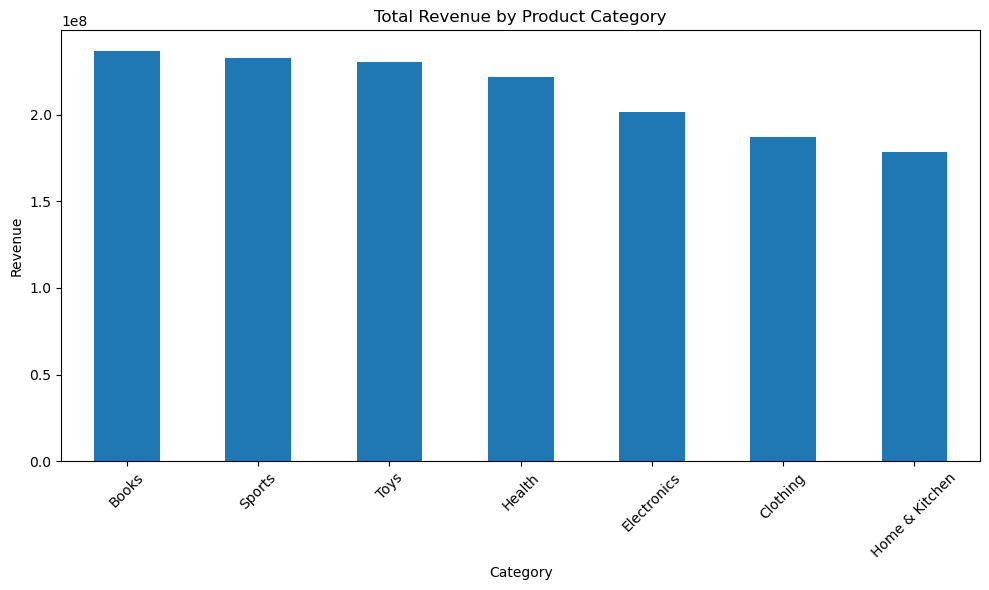

In [9]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
category_summary = (
    product_summary.groupby("category")
      .agg(
          products=("product_id", "nunique"),
          total_sales=("total_sales", "sum"),
          total_revenue=("total_revenue", "sum"),
          avg_price=("price", "mean"),
          avg_rating=("review_score", "mean"),
          total_reviews=("review_count", "sum"),
      )
)

print(category_summary)

                products  total_sales  total_revenue  avg_price  avg_rating  \
category                                                                      
Books                154       938229 236,782,805.60     251.38        3.10   
Clothing             140       826536 187,258,320.85     230.04        2.95   
Electronics          138       845120 201,674,684.07     239.67        3.14   
Health               139       834414 221,736,852.13     265.14        3.01   
Home & Kitchen       125       742141 178,365,505.26     239.77        3.04   
Sports               153       916371 232,648,831.88     254.22        3.09   
Toys                 151       917101 230,237,183.23     251.40        2.87   

                total_reviews  
category                       
Books                   79263  
Clothing                70347  
Electronics             73862  
Health                  72398  
Home & Kitchen          67735  
Sports                  83726  
Toys                    79175  


In [11]:
category_revenue = (
    product_summary.groupby("category")['total_revenue'].sum().sort_values(ascending=False)
)

print(category_revenue)

category
Books            236,782,805.60
Sports           232,648,831.88
Toys             230,237,183.23
Health           221,736,852.13
Electronics      201,674,684.07
Clothing         187,258,320.85
Home & Kitchen   178,365,505.26
Name: total_revenue, dtype: float64


In [12]:
category_summary["total_revenue"] = category_summary["total_revenue"].round(2)
category_summary["avg_price"] = category_summary["avg_price"].round(2)
category_summary["avg_rating"] = category_summary["avg_rating"].round(2)

category_summary

,products,total_sales,total_revenue,avg_price,avg_rating,total_reviews
category,,,,,,
Books,154,938229,"236,782,805.60",251.38,3.10,79263
Clothing,140,826536,"187,258,320.85",230.04,2.95,70347
Electronics,138,845120,"201,674,684.07",239.67,3.14,73862
Health,139,834414,"221,736,852.13",265.14,3.01,72398
Home & Kitchen,125,742141,"178,365,505.26",239.77,3.04,67735
Sports,153,916371,"232,648,831.88",254.22,3.09,83726
Toys,151,917101,"230,237,183.23",251.40,2.87,79175


As can be concluded from the plot, Books lead on revenue ($236.8M) and also sold the most units (938k). 